In [31]:

# nos librairies
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# affichons notre dataframe clean en fixant le type de la variable jour en datetimes
df = pd.read_csv("../data/covid_hospit_clean.csv", parse_dates=["jour"])
print(df.head())

  dep  sexe       jour  hosp  rea  HospConv  SSR_USLD  autres  rad  dc
0  01     0 2020-03-18     2    0       NaN       NaN     NaN    1   0
1  01     1 2020-03-18     1    0       NaN       NaN     NaN    1   0
2  01     2 2020-03-18     1    0       NaN       NaN     NaN    0   0
3  02     0 2020-03-18    41   10       NaN       NaN     NaN   18  11
4  02     1 2020-03-18    19    4       NaN       NaN     NaN   11   6


## KPI GLOGAUX

In [33]:
df.dtypes

dep                    str
sexe                 int64
jour        datetime64[us]
hosp                 int64
rea                  int64
HospConv           float64
SSR_USLD           float64
autres             float64
rad                  int64
dc                   int64
dtype: object

In [34]:
df.columns

Index(['dep', 'sexe', 'jour', 'hosp', 'rea', 'HospConv', 'SSR_USLD', 'autres',
       'rad', 'dc'],
      dtype='str')

### nous allons chercher les indicateurs pertinents

In [35]:
# nous allons afficher un descriptif de nos données

df[["hosp",	"rea","HospConv","SSR_USLD","autres","rad","dc"]].describe().round(2)

,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
count,338245.00,338245.00,228140.00,228140.00,228140.00,338245.00,338245.00
mean,113.80,13.36,61.50,35.98,2.99,2817.62,534.74
std,166.75,28.40,83.83,52.00,5.83,4173.61,730.47
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,23.00,1.00,15.00,6.00,0.00,500.00,105.00
50%,58.00,4.00,34.00,18.00,1.00,1404.00,278.00
75%,134.00,13.00,73.00,44.00,3.00,3338.00,653.00
max,3281.00,855.00,1115.00,565.00,170.00,48210.00,6463.00


Nous observons qu'il y'a un très grand écart entre le min et le max des différentes variables.
Ce ne sont pas de valeurs abbérantes.
Ici les grands chiffres sont normaux car :

la pandémie a duré 3 ans ;
il y a 338 245 observations ;
les indicateurs sont cumulés quotidiennement.

Si nous prenons par exemple le descriptif de la variable (hosp)
le nombre d'hospitalisé par jour varie de 0 à 3281 personnes avec une moyenne de 113,80 par jour qui repésente le double de sa médiane 58.

La majorité des observations présentent un nombre d'hospitalisations relativement faible, tandis qu'un nombre limité d'observations affiche des niveaux très élevés, ce qui tire la moyenne vers le haut.

De même concernant le nombre de personnes en réanimation (rea), on a un effectif qui varie en 0 et 855 avec une moyenne de 13,36 ce qui traduit que la plupart du temps, les services de réanimation fonctionnaient à un niveau modéré. Certaines périodes ont connu une forte pression hospitalière.

Concernant les décès (dc), on a entre 0 et 6463 décès par jour avec une moyenne de 534.74 et une médiane de 278. ce qui traduit quelques épisodes exceptionnels qui augmentent fortement les valeurs observées.
 


In [36]:
# nous pouvons oberver que les périodes qui a été les plus critiques dans les services hospitaliers en France était:
df.groupby("jour")["hosp"].sum().sort_values(ascending=False). head(10)

jour
2020-11-16    66605
2022-02-07    66417
2022-02-08    66233
2020-11-17    65964
2020-11-15    65759
2022-02-06    65562
2022-02-04    65492
2022-02-09    65297
2022-02-01    65287
2020-11-18    65285
Name: hosp, dtype: int64

On observe qu'il y'a eu une forte hospitalisation pendant les périodes de :
- Novembre 2020
- Février 2022

In [37]:
# les départements qui ont été les plus touchés par la pandémie cette période de 2020 à 2023 sont:
df.groupby("dep")["hosp"].sum().sort_values(ascending=False). head(10)

dep
75    1967155
13    1752745
59    1655530
92    1654392
93    1635225
94    1340362
69    1204623
78    1044302
91     900666
95     833454
Name: hosp, dtype: int64

On observe que les départements les plus affectés étaient : 75, 13, 59, 92, 93 on peut remarquer une forte représentation des départements de la région île-de-france.


In [38]:
# Nous filtrer et afficherons les résultats observer le dernier jour de la collecte des données dans l'ensemble des départements de la France
dernier_jour = df["jour"].max()

df[df["jour"] == dernier_jour][["hosp","rea","rad","dc"]].sum()

hosp      26065
rea        1413
rad     1719619
dc       271091
dtype: int64

In [39]:
df.groupby("jour")["dc"].max().tail()

jour
2023-03-27    6456
2023-03-28    6460
2023-03-29    6462
2023-03-30    6462
2023-03-31    6463
Name: dc, dtype: int64

Comme nous l'avons observer précédemment dans le fichier exploration que les cumuls hommes et femmes ont été construits indépendamment du cumul global.

Donc par exemple dc(sexe=0) n'est pas focément égale à dc(sexe=1) + dc(sexe=2) comme nous l'avons observé.


In [40]:
# nous allons réaliser 2 datasets à partir de notre df et afin d'avoir un avec sexe =0 et le second avec sexe=1 et 2
# Pour nos analyses globales, nous allons filtrer et obtenir df_total

df_total = df[df["sexe"]==0]
display(df_total.head())
display(df_total.tail())

,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
0,01,0,2020-03-18,2,0,NaN,NaN,NaN,1,0
3,02,0,2020-03-18,41,10,NaN,NaN,NaN,18,11
6,03,0,2020-03-18,4,0,NaN,NaN,NaN,1,0
9,04,0,2020-03-18,3,1,NaN,NaN,NaN,2,0
12,05,0,2020-03-18,8,1,NaN,NaN,NaN,9,0


,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
338231,972,0,2023-03-31,14,0,12.0,2.0,0.0,4669,1101
338234,973,0,2023-03-31,4,1,3.0,0.0,0.0,6330,410
338237,974,0,2023-03-31,27,5,14.0,8.0,0.0,8876,980
338240,976,0,2023-03-31,0,0,0.0,0.0,0.0,1766,163
338243,978,0,2023-03-31,0,0,0.0,0.0,0.0,0,0


In [41]:
# Pour les analyses par sexe nous allons filtrer et obtenir df_sex
df_sex = df[df["sexe"].isin([1,2])]
display(df_sex.head())
display(df_sex.tail())

,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
1,01,1,2020-03-18,1,0,NaN,NaN,NaN,1,0
2,01,2,2020-03-18,1,0,NaN,NaN,NaN,0,0
4,02,1,2020-03-18,19,4,NaN,NaN,NaN,11,6
5,02,2,2020-03-18,22,6,NaN,NaN,NaN,7,5
7,03,1,2020-03-18,1,0,NaN,NaN,NaN,0,0


,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
338238,974,1,2023-03-31,12,3,7.0,2.0,0.0,4177,544
338239,974,2,2023-03-31,15,2,7.0,6.0,0.0,4643,429
338241,976,1,2023-03-31,0,0,0.0,0.0,0.0,739,100
338242,976,2,2023-03-31,0,0,0.0,0.0,0.0,1002,61
338244,978,1,2023-03-31,0,0,0.0,0.0,0.0,0,0


In [42]:
print (f"df_total comptabilise {df_total.shape[0]} lignes et {df_total.shape[1]} colonnes , \n df_sexe comptabilise {df_sex.shape[0]} lignes et {df_sex.shape[1]} colonnes")


df_total comptabilise 113118 lignes et 10 colonnes , 
 df_sexe comptabilise 225127 lignes et 10 colonnes


Nous pouvons voir que df_sexe représente environ le double de notre df_total.

In [43]:
# nous allons faire une copie de notre df_sex sur laquelle nous allons faire nos premières analyses 
df_sex_copy = df_sex.copy()
display(df_sex_copy.head())


,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
1,01,1,2020-03-18,1,0,NaN,NaN,NaN,1,0
2,01,2,2020-03-18,1,0,NaN,NaN,NaN,0,0
4,02,1,2020-03-18,19,4,NaN,NaN,NaN,11,6
5,02,2,2020-03-18,22,6,NaN,NaN,NaN,7,5
7,03,1,2020-03-18,1,0,NaN,NaN,NaN,0,0


In [44]:
# le nombre d'hospitalisation moyen par sexe
display( "Moyenne:", df_sex_copy.groupby("sexe")["hosp"].mean())


'Moyenne:'

sexe
1    84.637776
2    85.284343
Name: hosp, dtype: float64

On observe approximativement la même moyenne  de femmes que d'hommes qui sont hospitalisés suite au Covid pendant cette période.

In [45]:
# le nombre de réanimation moyen par sexe
display( "Moyenne:", df_sex_copy.groupby("sexe")["rea"].mean().round(2))

'Moyenne:'

sexe
1    13.52
2     6.44
Name: rea, dtype: float64

In [46]:
# le nombre de décès moyen par sexe
display( "Moyenne:", df_sex_copy.groupby("sexe")["dc"].mean().round(2))

'Moyenne:'

sexe
1    459.81
2    340.18
Name: dc, dtype: float64

Nous observons qu'il y'a plus d'hommes que de femmes qui sont en moyenne entrés en réanimation et qui sont décédés suite à cette pandémie. Nous allons mieux observer cela via des analyses ci-dessous

### observons le comportement sur le dernier jour

In [47]:
#la derniere date disponible
dernier_jour = df_sex_copy["jour"].max()

# Le filtrer sur cette date
df_dernier_jour = df_sex_copy[df_sex_copy["jour"]==dernier_jour]

# agrégation par sexe

resultat_sexe = df_dernier_jour.groupby("sexe")[["hosp","rea","dc", "rad"]].sum()

display(resultat_sexe)

,hosp,rea,dc,rad
sexe,,,,
1,5919,446,77630,422089
2,6997,258,57385,433693


y'a -til eu autant d'hommes touchés que de femmes en termes d'hospitalisation, de réanimation et de décès ? et les retours à domicile qu'en est 'il?

In [48]:
# nous allons afficher les valeurs en pourcentages 
resultat_sexe["%hosp"] = round(resultat_sexe["hosp"]/resultat_sexe["hosp"].sum()*100)
resultat_sexe["%rea"] = round(resultat_sexe["rea"]/resultat_sexe["rea"].sum()*100)
resultat_sexe["%dc"] = round(resultat_sexe["dc"]/resultat_sexe["dc"].sum()*100)
resultat_sexe["%rad"] = round(resultat_sexe["rad"]/resultat_sexe["rad"].sum()*100)
display(resultat_sexe)

,hosp,rea,dc,rad,%hosp,%rea,%dc,%rad
sexe,,,,,,,,
1,5919,446,77630,422089,46.0,63.0,57.0,49.0
2,6997,258,57385,433693,54.0,37.0,43.0,51.0


### Observations
Les femmes sont légèrement plus nombreuses parmi les patients hospitalisés;
Concernant la réanimation: la différence est très forte.
Les hommes représentent près de deux tiers des patients en réanimation.
Concernant le décès: Les hommes présentent également une mortalité plus élevée.
Ce qui conduit à un taux un peu plus élévé de retour à domicile pour les femmes que pour les hommes.



### Conclusions de notre analyse liée au sexe
L'analyse par sexe met en évidence des différences notables dans l'impact de la pandémie.

Au dernier jour observé, les femmes représentent une part légèrement plus importante des hospitalisations (54 % contre 46 % pour les hommes). En revanche, les hommes sont davantage concernés par les formes graves de la maladie.

Ils représentent 63 % des patients admis en réanimation et 57 % des décès observés. Ces résultats suggèrent que les hommes ont été plus exposés aux complications sévères du Covid-19 malgré une proportion d'hospitalisations légèrement inférieure à celle des femmes.

Nous allons répondre à la question de savoir:
Quels départements ont subi la plus forte pression hospitalière pendant la pandémie ?

In [49]:
# nous allons faire une copie de notre df_total 
df_total_copy = df_total.copy()
display(df_total_copy.head())

,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
0,01,0,2020-03-18,2,0,NaN,NaN,NaN,1,0
3,02,0,2020-03-18,41,10,NaN,NaN,NaN,18,11
6,03,0,2020-03-18,4,0,NaN,NaN,NaN,1,0
9,04,0,2020-03-18,3,1,NaN,NaN,NaN,2,0
12,05,0,2020-03-18,8,1,NaN,NaN,NaN,9,0


In [50]:
# nous allons ressortir les 10 départements avec le plus d'hospitalisation
top10_hosp = df_total_copy.groupby("dep")["hosp"].max().sort_values(ascending=False).head(10)

top10_hosp

dep
75    3281
94    2278
92    2024
69    1913
59    1692
13    1649
93    1638
91    1231
67    1122
68    1105
Name: hosp, dtype: int64

Département	Pic d'hospitalisation
75 (Paris)	
94 (Val-de-Marne)	
92 (Hauts-de-Seine)	
69 (Rhône)	
59 (Nord)	
13 (Bouches-du-Rhône)	
93 (Seine-Saint-Denis)

### Observation

On retrouve principalement :

la région d'Île-de-France,
les grandes métropoles,
les zones très densément peuplées.

Ce qui est cohérent avec la propagation du Covid.

In [51]:
# nous allons ressortir les 10 départements avec le plus d'entrées en réa'
top10_rea = df_total_copy.groupby("dep")["rea"].max().sort_values(ascending=False).head(10)

top10_rea

dep
75    855
92    456
59    362
13    354
94    344
69    304
67    283
93    251
91    237
77    213
Name: rea, dtype: int64


### Observation

75(Paris) domine très largement avec environ le double du 92(Hauts-de-Seine)

On constate également :

Nord (59), Bouches-du-Rhône (13), Rhône (69) qui disposent de grands centres hospitaliers, tout comme Paris.

In [52]:
# nous allons ressortir les 10 départements avec le plus de décès
top10_dc = df_total_copy.groupby("dep")["dc"].max().sort_values(ascending=False).head(10)

top10_dc

dep
75    6463
13    6230
59    6029
69    4546
94    4105
92    3661
57    3339
93    3220
77    3066
83    2859
Name: dc, dtype: int64

### Observation

Paris reste le département le plus touché. Mais on a aussi le 13 (Bouches-du-Rhône) et le 59 ( Nord) qui suivent fortement.

Cela suggère que l'impact sanitaire a également été important hors Île-de-France.

### Conclusion générale de cette analyse

L'analyse départementale met en évidence une forte concentration de la pression hospitalière dans les zones les plus densément peuplées du territoire.

Paris (75) apparaît comme le département ayant enregistré les niveaux les plus élevés d'hospitalisation, de réanimation et de décès liés au Covid-19. Les départements de la petite couronne parisienne (92, 93 et 94) figurent également parmi les plus touchés.

Les départements du Nord (59), du Rhône (69) et des Bouches-du-Rhône (13) apparaissent régulièrement dans les premières positions, traduisant l'importance de la densité démographique et des grands pôles urbains dans la dynamique de la pandémie.

Ces résultats suggèrent que les territoires fortement urbanisés ont subi la plus forte pression hospitalière au cours de la période étudiée.


Observations graphique: analyse des vagues épidémiques dans le temps grâce aux observations graphiques.

Nous allons présentement identifier :

combien de vagues il y a eu, quand ont eu lieu les pics.

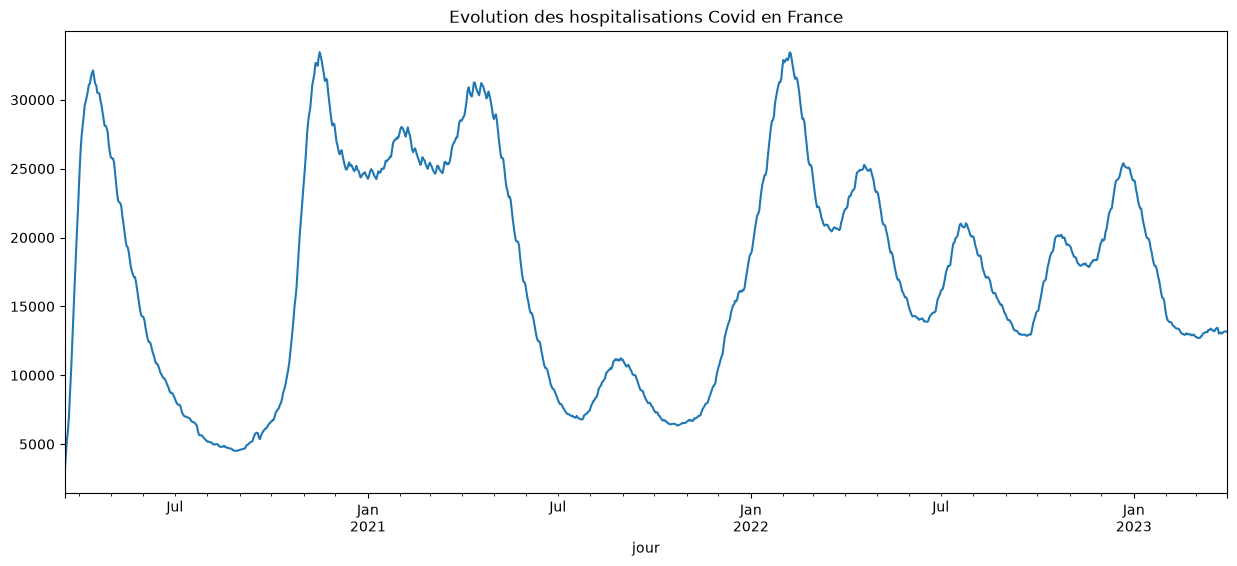

In [53]:
# analysons le comportement des hospitalisations enrégistrées

evolution_hosp = (
    df_total.groupby("jour")["hosp"]
    .sum()
)

evolution_hosp.plot(figsize=(15,6))
plt.title("Evolution des hospitalisations Covid en France")
plt.show()

## On observe clairement plusieurs vagues épidémiques.
Premier pic (première vague): printemps 2020 Vers mars-avril 2020 : environ 32 000

Deuxième pic (deuxième vague) : automne 2020 Vers novembre 2020 : environ 33 000

Troisième pic (troisième vague): printemps 2021 Vers mars-avril 2021 : environ 31 000

Pic maximal : début 2022

Vers janvier-février 2022 : environ 33 500 hospitalisations. C'est le maximum observé dans notre dataset.

Après 2022 :

On a plusieurs vagues mais moins violentes que les premiers pics.

Le système hospitalier parvient de mieux en mieux à contenir la crise comparer à 2020 avant crise.

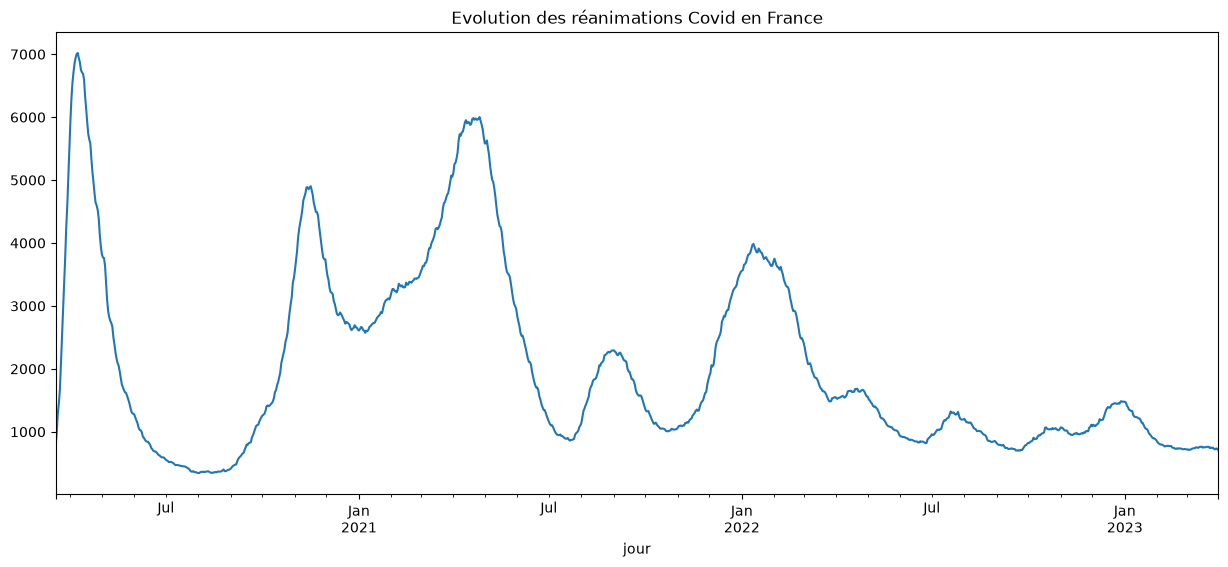

In [54]:
# analysons le comportement des enregistrements en réanimations

evolution_rea = (
    df_total.groupby("jour")["rea"]
    .sum()
)

evolution_rea.plot(figsize=(15,6))
plt.title("Evolution des réanimations Covid en France")
plt.show()

Analyse du graphique des réanimations : Nous avons des observations intéressantes.

Premier pic Mars-avril 2020 : environ 7 000 patients en réanimation qui représente le maximum de notre dataset.

Deuxième phase importante Printemps 2021 : environ 6 000 patients qui représente une très forte pression également.

ON observe un changement majeur après 2021

On observe que :

les hospitalisations restent élevées tandis que les réanimations diminuent fortement.

Par exemple :

2022 :
environ 33 000 hospitalisations
et environ 4 000 réanimations

## on peut donc dire que:

À partir de 2022, le nombre d'hospitalisations reste élevé tandis que le nombre de patients admis en réanimation diminue significativement. Cette évolution suggère une réduction de la gravité moyenne des cas pris en charge à l'hôpital et une meilleure gestion des cas critiques.

### en générale:

#### Hospitalisations

Les hospitalisations présentent plusieurs vagues successives entre 2020 et 2023. Le niveau maximal est atteint début 2022 avec plus de 33 000 patients hospitalisés simultanément.

#### Réanimations

La pression sur les services de réanimation est particulièrement forte lors des premières vagues. Le pic historique est observé au printemps 2020 avec près de 7 000 patients en réanimation.

### Conclusion

Malgré des niveaux d'hospitalisation encore élevés en 2022, les admissions en réanimation diminuent fortement, traduisant une meilleure prise en charge et une moindre gravité des formes prises en charge.

In [63]:
# Observons à présent le l'effectif moyen des patients hospitalisés sur chaque année durant cette période
df_total_hosp_an_moy = df_total_copy.groupby(df_total_copy["jour"].dt.year)["hosp"].mean().round(2)
print(df_total_hosp_an_moy)

jour
2020    155.03
2021    161.39
2022    198.92
2023    150.61
Name: hosp, dtype: float64


In [64]:
# Observons à présent le l'effectif moyen des patients reçus en réanimation sur chaque année durant cette période
df_total_rea_an_moy = df_total_copy.groupby(df_total_copy["jour"].dt.year)["rea"].mean().round(2)
print(df_total_rea_an_moy)

jour
2020    21.83
2021    26.37
2022    15.16
2023     8.72
Name: rea, dtype: float64


In [79]:
# Concaténer les deux DataFrames sur l'axe des colonnes 
df_total_hosp_rea_an_moy = pd.concat([df_total_hosp_an_moy, df_total_rea_an_moy], axis=1).reset_index()

# Renommer la colonne 'jour' en 'year'

df_total_hosp_rea_an_moy = df_total_hosp_rea_an_moy.rename(columns={'jour': 'annee'})

display(df_total_hosp_rea_an_moy)

,annee,hosp,rea
0,2020,155.03,21.83
1,2021,161.39,26.37
2,2022,198.92,15.16
3,2023,150.61,8.72


2021 est l'année avec la plus forte pression en réanimation.
2022 présente les hospitalisations moyennes les plus élevées.
2023 montre une forte baisse des hospitalisations et des réanimations.

### on peut dire que :

Les hospitalisations moyennes atteignent leur niveau le plus élevé en 2022 (198,92 patients en moyenne par département et par jour), tandis que la pression sur les services de réanimation atteint son maximum en 2021 (26,37 patients en moyenne). En 2023, les deux indicateurs diminuent fortement, traduisant un recul de la pression hospitalière liée au Covid-19.

Maintenant nous allons étudier les pics annuels

In [86]:
df_total_hosp_rea_an_pic = pd.concat(
    [df_total_copy.groupby(df_total_copy["jour"].dt.year)["hosp"].max(),
     
df_total_copy.groupby(df_total_copy["jour"].dt.year)["rea"].max()
    ], 
    axis=1).reset_index(
        names="annee")
print(df_total_hosp_rea_an_pic)

   annee  hosp  rea
0   2020  3281  855
1   2021  1813  570
2   2022  1868  314
3   2023  1226   96


Nous pouvons constater que:
2020 = plus fort pic d'hospitalisation
2020 = plus fort pic de réanimation
ce qui pourrait traduire que la première vague où les hôpitaux étaient les plus sous pression.
Les pics diminuent progressivement.

Après ces moyennes et ces pics on peut voir une très forte vague brutale en 2020.
tandisqu'une pression plus durable mais moins extrême en 2022.


Suite à ces obervations:

L'analyse des pics annuels montre que la première année de la pandémie (2020) a concentré les niveaux les plus élevés d'hospitalisation et de réanimation. Les années suivantes présentent des pics moins élevés, malgré des niveaux moyens d'hospitalisation parfois supérieurs. Cette situation suggère que la pression hospitalière est devenue plus diffuse dans le temps après les premières vagues de la pandémie. 


Nous allons pour plus de clarté Identifier les dates exactes des pics nationaux

In [94]:
jour_pic_hosp = df_total_copy.groupby("jour")["hosp"].sum().idxmax()
print(f"le jour du pic d hospitalisation est : {jour_pic_hosp}")

le jour du pic d hospitalisation est : 2020-11-16 00:00:00


In [95]:
valeur_pic_hosp = df_total_copy.groupby("jour")["hosp"].sum().max()
print(f"la valeur du pic d hospitalisation est : {valeur_pic_hosp}")

la valeur du pic d hospitalisation est : 33466


In [96]:
jour_pic_rea = df_total_copy.groupby("jour")["rea"].sum().idxmax()
print(f"le jour du pic au service reanimation est : {jour_pic_rea}")

le jour du pic au service reanimation est : 2020-04-08 00:00:00


In [97]:
valeur_pic_rea = df_total_copy.groupby("jour")["rea"].sum().max()
print(f"la valeur du pic au service reanimation est : {valeur_pic_rea}")

la valeur du pic au service reanimation est : 7019


Analyse des pics hospitaliers

Le nombre maximal d'hospitalisations a été observé le 16/11/2020 avec  33 466 patients hospitalisés simultanément en France.

Ce résultat confirme l'intensité de la deuxième vague épidémique de l'automne 2020, qui a fortement mobilisé les capacités hospitalières françaises.

Analyse des pics de réanimation

Le nombre maximal au service réanimation a été observé le 08/04/2020 avec  7 019 patients en réanimation simultanément dans tous les départements de France.

Ce pic correspond à la première vague de la pandémie et représente la période de plus forte pression sur les services de soins critiques.

Nous allons continuer l'analyse et ressortir les KPIs sur le dataset kpi_total_jour qui regroupe les hospitatisations, réanimations, décès et retour à domicile.


In [ ]:
kpi_total_jour = (
    df_total.groupby("jour")[["hosp","rea","dc","rad"]]
    .sum()
)

kpi_total_jour.to_csv(
    "../data/kpi_total_jour.csv",
    index=True
)